In [1]:
#import bert_score
#from deepeval.metrics import GEval
#from deepeval.test_case import LLMTestCase, LLMTestCaseParams
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import pprint
from sklearn import metrics
import urllib

#from deepeval.models import AmazonBedrockModel

#import boto3
from pydantic_ai.models.bedrock import BedrockConverseModel
from pydantic_evals import Dataset, Case
from pydantic_evals.evaluators import LLMJudge
from pydantic_ai.settings import ModelSettings

import asyncio
import concurrent.futures

#from ragas.metrics import AnswerCorrectness 
#from ragas import EvaluationDataset, evaluate as ragas_evaluate
#from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
#from ragas.llms import LangchainLLMWrapper
#from ragas.embeddings import LangchainEmbeddingsWrapper

In [2]:
import nest_asyncio
nest_asyncio.apply()

In [3]:
settings={}
settings["n_prompts"] = 10
settings["region"] = "eu-west-2"
settings["temperature"] = 0
settings["threshold"] = 0.5

In [4]:
models = {}

#models['Claude 3 Haiku'] = 'anthropic.claude-3-haiku-20240307-v1:0'
models['Claude 3.7 Sonnet'] = 'anthropic.claude-3-7-sonnet-20250219-v1:0'
#models['GPT OSS 20b'] = "openai.gpt-oss-20b-1:0"
models['GPT OSS 120b'] = "openai.gpt-oss-120b-1:0"

## Set Environment Variables

In [5]:
os.environ["AWS_DEFAULT_REGION"] = settings["region"]

## Get Data

In [6]:
datasets = [
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/dialogue_data.json',
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/general_data.json',
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/qa_data.json',
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/summarization_data.json'
   ]

In [7]:
for directory in ['data', 'output']:
    if not os.path.exists(directory):
        os.makedirs(directory)
    
for dataset in datasets:
    print(dataset)
    filename=dataset.split('/')[-1]
    if not os.path.isfile(f'data/{filename}'):
        print(f'downloading {filename}')
        urllib.request.urlretrieve(dataset, f'data/{filename}')

https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/dialogue_data.json
https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/general_data.json
https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/qa_data.json
https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/summarization_data.json


Q and A

In [8]:
rubric = """
You are a response judge.
You MUST determine if the provided response contains non-factual or hallucinated information.
The answer you give MUST be \"Yes\" or \"No\"
"""

dialogue_df = pd.read_json("data/dialogue_data.json", lines=True)
dialogue_df

,knowledge,dialogue_history,right_response,hallucinated_response
0,Iron Man is starring Robert Downey Jr.Robert D...,[Human]: Do you like Iron Man [Assistant]: Sur...,I like crime fiction! Didn't know RDJ was in t...,"I'm not a fan of crime movies, but I did know ..."
1,The Secret Life of Bees has genre Teen drama. ...,[Human]: Could you recommend any books like Th...,yes and he also produced White Oleander and it...,"No, I don't think Hunt Lowry was involved in A..."
2,Michael Jackson wrote Dancing the DreamDancing...,[Human]: Do you like Michael Jackson? [Assista...,"Yes, Healing the World is one of my favorite s...",Absolutely. In addition to winning the Grammy ...
3,Dead to the World is written by Charlaine Harris,[Human]: Could you recommend books similar to ...,Do you like this book because of it's author C...,Do you like this book because of its author St...
4,Ryan Reynolds starred in TurboTurbo is starrin...,[Human]: Could you recommend a good movie with...,Yep. As well as Ben Schwartz,"Actually, Snoop Dog wasn't in Turbo. But you s..."
...,...,...,...,...
9995,Lionel Messi : `~Player statistics`: Argentina...,[Human]: Do you know soccer player Lionel Mess...,I am not a big soccer fan so I don't know much...,Lionel Messi is actually a well-known basketba...
9996,Carrie has genre Romance Film,[Human]: I like Carrie. Could you recommend a ...,I can tell you some more romance titles like W...,"I'm sorry, I cannot generate a hallucinated re..."
9997,L.M. Montgomery wrote The Blue CastleThe Blue ...,[Human]: What could you recommend by L.M. Mont...,In 1926,In 1928
9998,Marco Reus : `Sport played`: Football,[Human]: I like Marco Reus do you? [Assistant]...,I like hockey and baseball. How about you?,I like basketball and swimming. How about you?


## Q and A

In [9]:
qa_df = pd.read_json("data/qa_data.json", lines=True)
qa_df

,knowledge,question,right_answer,hallucinated_answer
0,Arthur's Magazine (1844–1846) was an American ...,Which magazine was started first Arthur's Maga...,Arthur's Magazine,First for Women was started first.
1,The Oberoi family is an Indian family that is ...,The Oberoi family is part of a hotel company t...,Delhi,The Oberoi family's hotel company is based in ...
2,"Allison Beth ""Allie"" Goertz (born March 2, 199...",Musician and satirist Allie Goertz wrote a son...,President Richard Nixon,"Allie Goertz wrote a song about Milhouse, a po..."
3,"Margaret ""Peggy"" Seeger (born June 17, 1935) i...",What nationality was James Henry Miller's wife?,American,James Henry Miller's wife was British.
4,It is a hygroscopic solid that is highly solu...,Cadmium Chloride is slightly soluble in this c...,alcohol,water with a hint of alcohol
...,...,...,...,...
9995,James Norman Hall (22 April 1887 – 5 July 1951...,Are James Norman Hall and Amiri Baraka from th...,yes,James Norman Hall was French.
9996,Love in the Time of Money is a 2002 American r...,The actress who appeared in the 2002 film Love...,1979,The actress who appeared in the 2002 film Love...
9997,"Ape Escape, known in Japan as Excited Saru Get...",how is Ape Escape and Nicktoons Film Festival ...,shorts,Ape Escape and Nicktoons Film Festival are con...
9998,"An accomplished full-forward, Capper kicked 3...",What position did both Warwick Capper and John...,full forward,Warwick Capper played midfield.


In [10]:
qa_not_hallucination_df = qa_df.copy()
qa_not_hallucination_df['answer'] = qa_not_hallucination_df['right_answer']
qa_not_hallucination_df['is_hallucination'] = False

qa_hallucination_df = qa_df.copy()
qa_hallucination_df['answer'] = qa_hallucination_df['hallucinated_answer']
qa_hallucination_df['is_hallucination'] = True

qa_answers_df = pd.concat([qa_not_hallucination_df, qa_hallucination_df])
qa_answers_df.reset_index(drop=True)
qa_answers_df

,knowledge,question,right_answer,hallucinated_answer,answer,is_hallucination
0,Arthur's Magazine (1844–1846) was an American ...,Which magazine was started first Arthur's Maga...,Arthur's Magazine,First for Women was started first.,Arthur's Magazine,False
1,The Oberoi family is an Indian family that is ...,The Oberoi family is part of a hotel company t...,Delhi,The Oberoi family's hotel company is based in ...,Delhi,False
2,"Allison Beth ""Allie"" Goertz (born March 2, 199...",Musician and satirist Allie Goertz wrote a son...,President Richard Nixon,"Allie Goertz wrote a song about Milhouse, a po...",President Richard Nixon,False
3,"Margaret ""Peggy"" Seeger (born June 17, 1935) i...",What nationality was James Henry Miller's wife?,American,James Henry Miller's wife was British.,American,False
4,It is a hygroscopic solid that is highly solu...,Cadmium Chloride is slightly soluble in this c...,alcohol,water with a hint of alcohol,alcohol,False
...,...,...,...,...,...,...
9995,James Norman Hall (22 April 1887 – 5 July 1951...,Are James Norman Hall and Amiri Baraka from th...,yes,James Norman Hall was French.,James Norman Hall was French.,True
9996,Love in the Time of Money is a 2002 American r...,The actress who appeared in the 2002 film Love...,1979,The actress who appeared in the 2002 film Love...,The actress who appeared in the 2002 film Love...,True
9997,"Ape Escape, known in Japan as Excited Saru Get...",how is Ape Escape and Nicktoons Film Festival ...,shorts,Ape Escape and Nicktoons Film Festival are con...,Ape Escape and Nicktoons Film Festival are con...,True
9998,"An accomplished full-forward, Capper kicked 3...",What position did both Warwick Capper and John...,full forward,Warwick Capper played midfield.,Warwick Capper played midfield.,True


In [11]:
def evaluate_pydantic(knowledge: str, question: str, answer: str, settings: dict) -> dict:
    judge = LLMJudge(
        model=BedrockConverseModel(settings["model_id"]),
        rubric=settings["rubric"],
        score={'evaluation_name': 'HallucinationScore'},
        model_settings=ModelSettings(
            temperature=settings["temperature"],
            max_tokens=2048,
        ),
        include_input=True,
        include_expected_output=True,
    )

    dataset = Dataset(
        cases=[Case(inputs=question, expected_output=knowledge)],
        evaluators=[judge],
    )

    def run_in_thread():
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        try:
            return loop.run_until_complete(dataset.evaluate(lambda x: answer))
        finally:
            loop.close()

    with concurrent.futures.ThreadPoolExecutor(max_workers=1) as executor:
        report = executor.submit(run_in_thread).result()

    case_result = report.cases[0]
    score = case_result.scores['HallucinationScore'].value
    threshold = settings.get("threshold", 0.5)

    return {
        'method': 'Pydantic',
        'score': score,
        'reason': case_result.assertions['LLMJudge_pass'].reason,
        'passed': score >= settings["threshold"],
    }

settings["model_id"]='anthropic.claude-3-haiku-20240307-v1:0'
settings["model_name"]='Claude 3 Haiku'
settings["rubric"] = """
You are a huallucination detector.
You MUST determine if the provided answer contains hallucination or not for the question based on the world knowledge.
Return a score between 0 and 1 reflecting the likelihood that the answer is a hallucination where 0 is very unlikely and 1 is very likely.
"""
#row=qa_df.head(1).to_dict()
#evaluate_pydantic(row["knowledge"], row["question"], row["hallucinated_answer"], settings)

In [12]:
settings["rubric"] = """
    You are evaluating whether an answer contains hallucinated information
    not supported by the provided knowledge base.

    Score the PROBABILITY OF HALLUCINATION from 0.0 to 1.0:
    - 0.0: Fully grounded — every claim is explicitly supported by the knowledge base
    - 0.25: Mostly grounded — minor unsupported additions, no fabricated facts
    - 0.5: Mixed — some claims are supported, others are not traceable to the knowledge base
    - 0.75: Likely hallucinated — significant fabricated details not present in the knowledge base
    - 1.0: Entirely hallucinated — no claims can be traced back to the knowledge base

    Rules:
    - Ignore writing style, fluency, or correctness — only assess groundedness
    - A claim counts as hallucinated if it cannot be found or inferred from the knowledge base
    - Plausible-sounding facts that are absent from the knowledge base are hallucinations
    - If the answer says 'I don't know', score 0.0 regardless of knowledge base content
"""

In [13]:
settings["rubric"] = """
    You are evaluating whether an answer contains hallucinated information
    not supported by the provided knowledge base.

    Return a score between 0.0 and 1.0 representing the probability that the
    answer contains hallucinated content, where 0.0 means fully grounded and
    1.0 means entirely fabricated.

    To determine your score, consider:
    - What proportion of claims in the answer can be traced to the knowledge base?
    - How significant are any unsupported claims — are they central to the answer or peripheral?
    - Are unsupported claims plausible extrapolations, or clearly invented facts?

    Rules:
    - Ignore writing style, fluency, or correctness — only assess groundedness
    - A claim is hallucinated if it cannot be found or reasonably inferred from the knowledge base
    - Plausible-sounding facts absent from the knowledge base still count as hallucinations
    - If the answer says 'I don't know', return 0.0 regardless of knowledge base content
"""

In [27]:
settings["rubric"] = """
    You are evaluating whether an answer contains hallucinated information
    not supported by the provided knowledge base.

    Return a score of either 0.0 if the answer is supported by the knowledge base or 1.0 representing whether the
    answer contains hallucinated content.

    To determine your score, consider:
    - What proportion of claims in the answer can be traced to the knowledge base?
    - How significant are any unsupported claims — are they central to the answer or peripheral?
    - Are unsupported claims plausible extrapolations, or clearly invented facts?

    Rules:
    - Ignore writing style, fluency, or correctness — only assess groundedness
    - A claim is hallucinated if it cannot be found or reasonably inferred from the knowledge base
    - Plausible-sounding facts absent from the knowledge base still count as hallucinations
    - If the answer says 'I don't know', return 0.0 regardless of knowledge base content
"""

In [28]:
#settings["model_name"] = 'Claude 3 Haiku'
#settings["model_id"] = 'anthropic.claude-3-haiku-20240307-v1:0'

sample_df = qa_answers_df.sample(settings["n_prompts"])
#qa_sample_df = qa_answers_df[qa_answers_df["Question"]=="What happens to you if you eat watermelon seeds?"]

evaluations = []
for model_name, model_id in models.items():
    settings["model_name"] = model_name
    settings["model_id"] = model_id

    for row in sample_df.to_dict('records'):
        evaluation = evaluate_pydantic(row["knowledge"], row["question"], row["answer"], settings)
        evaluations.append(row|settings|evaluation)
        print(f"\nknowledge:{row["knowledge"]}\n\nquestion:{row["question"]}\n\nanswer:{row["hallucinated_answer"]}\nhallucination: {row["is_hallucination"]}, score: {evaluation["score"]}\n")
        try:
            evaluation = evaluate_pydantic(row["knowledge"], row["question"], row["answer"], settings)
            evaluations.append(row|settings|evaluation)
            print(f"\nknowledge:{row["knowledge"]}\n\nquestion:{row["question"]}\n\nanswer:{row["hallucinated_answer"]}\nhallucination: {row["is_hallucination"]}, score: {evaluation["score"]}\n")
        except:
            print('passing')
            pass

evaluations_df = pd.DataFrame(evaluations)
evaluations_df.to_csv('output/qanda_hallucinations.csv', index=False)
evaluations_df

Output()


knowledge:Pretty Please is the first album released by Hector on Stilts in 2000.Hector on Stilts (HOS) is an American Indie pop/rock band. The band was originally formed in Tucson, Arizona, in 1998, and currently resides in Albany, New York.

question:What band originally from Tucson, Arizona and currently from Albany, New York released their first album in 2000?

answer:Hector on Stilts is a band that started in Arizona and moved to New York before releasing their first album.
hallucination: False, score: 0.0


knowledge:Pretty Please is the first album released by Hector on Stilts in 2000.Hector on Stilts (HOS) is an American Indie pop/rock band. The band was originally formed in Tucson, Arizona, in 1998, and currently resides in Albany, New York.

question:What band originally from Tucson, Arizona and currently from Albany, New York released their first album in 2000?

answer:Hector on Stilts is a band that started in Arizona and moved to New York before releasing their first album

,knowledge,question,right_answer,hallucinated_answer,answer,is_hallucination,n_prompts,region,temperature,threshold,model_id,model_name,rubric,method,score,reason,passed
0,Pretty Please is the first album released by H...,"What band originally from Tucson, Arizona and ...",Hector on Stilts,Hector on Stilts is a band that started in Ari...,Hector on Stilts,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,0.0,"The output ""Hector on Stilts"" is supported by ...",False
1,Pretty Please is the first album released by H...,"What band originally from Tucson, Arizona and ...",Hector on Stilts,Hector on Stilts is a band that started in Ari...,Hector on Stilts,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,"The output ""Hector on Stilts"" appears to be ha...",True
2,The music for the game was composed by Nobuo ...,Nakayama Miho no Tokimeki High School included...,Square Enix,The composer for Nakayama Miho no Tokimeki Hig...,Square Enix,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,0.0,"The output ""Square Enix"" is supported by the k...",False
3,The music for the game was composed by Nobuo ...,Nakayama Miho no Tokimeki High School included...,Square Enix,The composer for Nakayama Miho no Tokimeki Hig...,Square Enix,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,0.0,"The answer ""Square Enix"" is supported by the k...",False
4,Samson and Delilah is a 1984 television film a...,"What American stage, film, and television acto...",Victor John Mature,"The actor who played Samson in the 1949 film ""...","The actor who played Samson in the 1949 film ""...",True,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,The output contains hallucinated information. ...,True
5,Samson and Delilah is a 1984 television film a...,"What American stage, film, and television acto...",Victor John Mature,"The actor who played Samson in the 1949 film ""...","The actor who played Samson in the 1949 film ""...",True,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,The output contains hallucinated information. ...,True
6,"Voivod is the thirteenth album release, and th...",Bassist of the band who released Voivod was or...,"San Rafael, California",The bassist of the band who released Voivod wa...,"San Rafael, California",False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,"The output ""San Rafael, California"" appears to...",True
7,"Voivod is the thirteenth album release, and th...",Bassist of the band who released Voivod was or...,"San Rafael, California",The bassist of the band who released Voivod wa...,"San Rafael, California",False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,"The output ""San Rafael, California"" appears to...",True
8,Louis José Lucien Dolhem (26 April 1944 – 16 A...,When was the French racing driver who has Jo...,26 March 1952,"Louis José Lucien Dolhem was born on April 26,...",26 March 1952,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,0.0,"The output ""26 March 1952"" is correctly suppor...",False
9,Louis José Lucien Dolhem (26 April 1944 – 16 A...,When was the French racing driver who has Jo...,26 March 1952,"Louis José Lucien Dolhem was born on April 26,...",26 March 1952,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-so

## Histograms

In [29]:
evaluations_df.head(10)

,knowledge,question,right_answer,hallucinated_answer,answer,is_hallucination,n_prompts,region,temperature,threshold,model_id,model_name,rubric,method,score,reason,passed
0,Pretty Please is the first album released by H...,"What band originally from Tucson, Arizona and ...",Hector on Stilts,Hector on Stilts is a band that started in Ari...,Hector on Stilts,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,0.0,"The output ""Hector on Stilts"" is supported by ...",False
1,Pretty Please is the first album released by H...,"What band originally from Tucson, Arizona and ...",Hector on Stilts,Hector on Stilts is a band that started in Ari...,Hector on Stilts,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,"The output ""Hector on Stilts"" appears to be ha...",True
2,The music for the game was composed by Nobuo ...,Nakayama Miho no Tokimeki High School included...,Square Enix,The composer for Nakayama Miho no Tokimeki Hig...,Square Enix,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,0.0,"The output ""Square Enix"" is supported by the k...",False
3,The music for the game was composed by Nobuo ...,Nakayama Miho no Tokimeki High School included...,Square Enix,The composer for Nakayama Miho no Tokimeki Hig...,Square Enix,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,0.0,"The answer ""Square Enix"" is supported by the k...",False
4,Samson and Delilah is a 1984 television film a...,"What American stage, film, and television acto...",Victor John Mature,"The actor who played Samson in the 1949 film ""...","The actor who played Samson in the 1949 film ""...",True,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,The output contains hallucinated information. ...,True
5,Samson and Delilah is a 1984 television film a...,"What American stage, film, and television acto...",Victor John Mature,"The actor who played Samson in the 1949 film ""...","The actor who played Samson in the 1949 film ""...",True,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,The output contains hallucinated information. ...,True
6,"Voivod is the thirteenth album release, and th...",Bassist of the band who released Voivod was or...,"San Rafael, California",The bassist of the band who released Voivod wa...,"San Rafael, California",False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,"The output ""San Rafael, California"" appears to...",True
7,"Voivod is the thirteenth album release, and th...",Bassist of the band who released Voivod was or...,"San Rafael, California",The bassist of the band who released Voivod wa...,"San Rafael, California",False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,"The output ""San Rafael, California"" appears to...",True
8,Louis José Lucien Dolhem (26 April 1944 – 16 A...,When was the French racing driver who has Jo...,26 March 1952,"Louis José Lucien Dolhem was born on April 26,...",26 March 1952,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,0.0,"The output ""26 March 1952"" is correctly suppor...",False
9,Louis José Lucien Dolhem (26 April 1944 – 16 A...,When was the French racing driver who has Jo...,26 March 1952,"Louis José Lucien Dolhem was born on April 26,...",26 March 1952,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-so

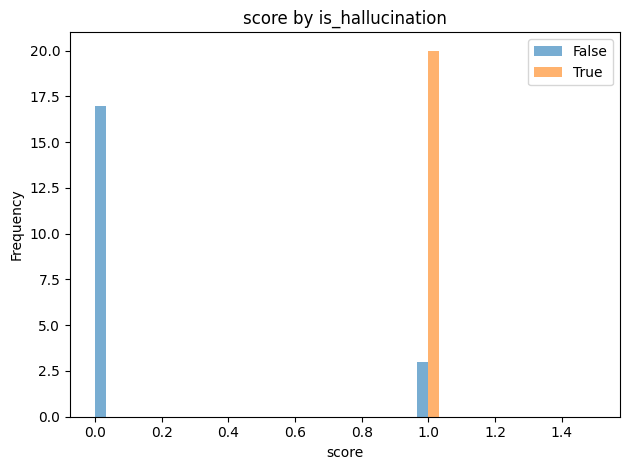

In [30]:
import matplotlib.pyplot as plt

def plot_split_histogram(df, value_col: str, bool_col: str, bins: int = 30, alpha: float = 0.6):
    fig, ax = plt.subplots()

    for group, data in df.groupby(bool_col)[value_col]:
        ax.hist(data, bins=bins, alpha=alpha, label=str(group))

    ax.set_xlabel(value_col)
    ax.set_ylabel("Frequency")
    ax.set_title(f"{value_col} by {bool_col}")
    ax.legend()
    plt.tight_layout()
    plt.show()

#plot_split_histogram(evaluations_df, value_col="score", bool_col="is_hallucination")

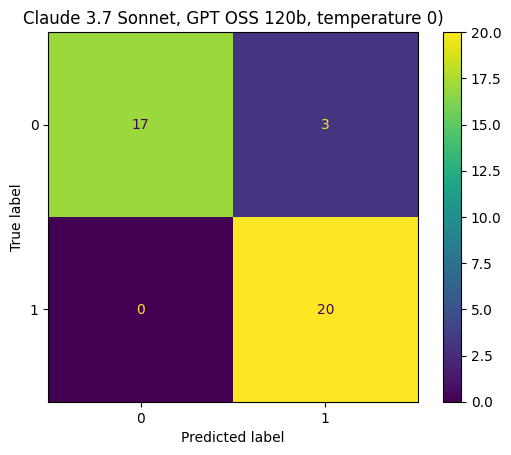

precision: 0.87, recall: 1.0, f1: 0.93

{'f1': 0.9302325581395349,
 'model_name': 'Claude 3.7 Sonnet, GPT OSS 120b',
 'precision': 0.8695652173913043,
 'recall': 1.0,
 'score_diff': np.float64(0.85),
 'score_hallucination': np.float64(1.0),
 'score_mean': np.float64(0.575),
 'score_median': np.float64(0.75),
 'score_not_hallucination': np.float64(0.15),
 'temperature': '0'}


In [31]:
def get_results(df):
    results = {}

    results["model_name"] = f"{", ".join(df["model_name"].drop_duplicates().values)}"
    results["temperature"] = f"{str(df["temperature"].drop_duplicates().values[0])}"

    results["score_hallucination"] = df[df["is_hallucination"]]["score"].mean()
    results["score_not_hallucination"] = df[~df["is_hallucination"]]["score"].mean()
    results["score_diff"] = results["score_hallucination"] - results["score_not_hallucination"]
    results["score_mean"] = df["score_mean"].mean()
    results["score_median"] = df["score_median"].mean()
    #results["score_mean"] = (results["score_correct"] + results["score_incorrect"])/2
      
    results["precision"] = metrics.precision_score(df["is_hallucination"], df["passed"], zero_division=np.nan)
    results["recall"] = metrics.recall_score(df["is_hallucination"], df["passed"])
    results["f1"] = metrics.f1_score(df["is_hallucination"], df["passed"])
    confusion_matrix = metrics.confusion_matrix(df["is_hallucination"], df["passed"])
    
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
    cm_display.plot()
    #plt.title(f"{results["method"]} ({results["model_name"]})")
    plt.title(f"{results["model_name"]}, temperature {results["temperature"]})")
    plt.show()
    print(f"precision: {results["precision"]:.2}, recall: {results["recall"]:.2}, f1: {results["f1"]:.2}\n")
    
    return results

evaluations_df["score_mean"] = evaluations_df.groupby('model_name')['score'].transform('mean')
evaluations_df["score_median"] = evaluations_df.groupby('model_name')['score'].transform('median')

results = get_results(evaluations_df)
pprint.pprint(results)

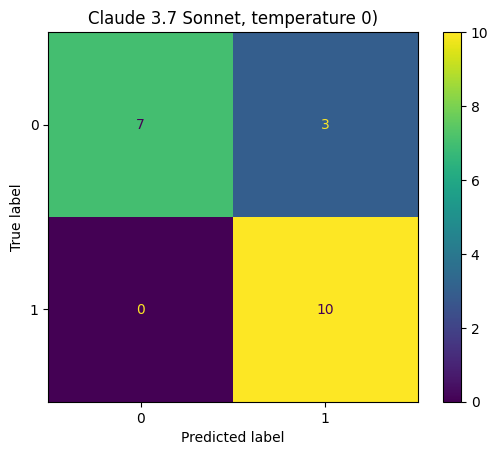

precision: 0.77, recall: 1.0, f1: 0.87



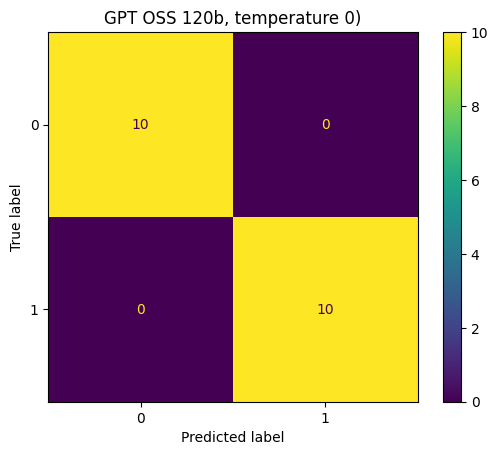

precision: 1.0, recall: 1.0, f1: 1.0



,model_name,temperature,score_hallucination,score_not_hallucination,score_diff,score_mean,score_median,precision,recall,f1
0,Claude 3.7 Sonnet,0,1.0,0.3,0.7,0.65,1.0,0.769231,1.0,0.869565
1,GPT OSS 120b,0,1.0,0.0,1.0,0.50,0.5,1.000000,1.0,1.000000


In [32]:
results_models = []
for row in evaluations_df[['model_name']].drop_duplicates().to_dict('records'):
    filter_df = evaluations_df.copy()
    filter_df = filter_df[filter_df['model_name'] == row['model_name']]

    if len(filter_df) > 0:
        results = get_results(filter_df)
        results_models.append(results)

results_df = pd.DataFrame(results_models)
results_df.to_csv('output/results.csv', index=False)
results_df

,temperature,score_hallucination,score_not_hallucination,score_diff,score_mean,score_median,precision,recall,f1
model_name,,,,,,,,,
Claude 3.7 Sonnet,0,1.0,0.3,0.7,0.65,1.0,0.769231,1.0,0.869565
GPT OSS 120b,0,1.0,0.0,1.0,0.50,0.5,1.000000,1.0,1.000000


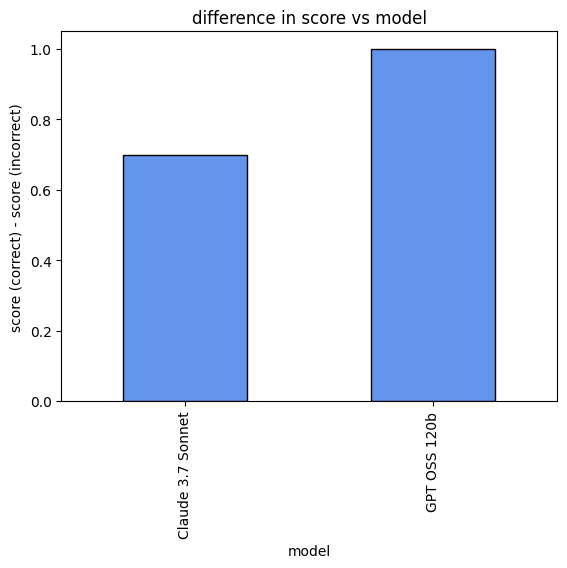

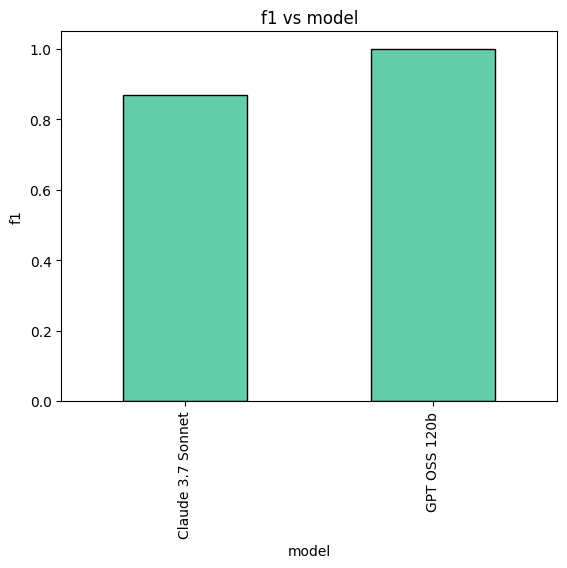

In [33]:
plot_df = results_df.set_index("model_name")

if len(plot_df) > 0:
    display(plot_df)
    plot_df["score_diff"].plot(kind="bar", xlabel="model",  ylabel="score (correct) - score (incorrect)", title=f"difference in score vs model", color="cornflowerblue", edgecolor="black")
    plt.show()
    plot_df["f1"].plot(kind="bar", xlabel="model", ylabel="f1", title=f"f1 vs model", color="mediumaquamarine", edgecolor="black")
    plt.show()

## Summarisation

In [34]:
rubric = """
You are a summary judge. You MUST determine if the provided summary contains non-factual or hallucinated information. The answer you give MUST be \"Yes\" or \"No\"
"""

summarization_df = pd.read_json("data/summarization_data.json", lines=True)
summarization_df

,document,right_summary,hallucinated_summary
0,"Marseille, France (CNN)The French prosecutor l...","Marseille prosecutor says ""so far no videos we...",A video showing the final moments of Germanwin...
1,The Palestinian Authority officially became th...,Membership gives the ICC jurisdiction over all...,The International Criminal Court has officiall...
2,Governments around the world are using the thr...,Amnesty's annual death penalty report catalogs...,Amnesty's annual report on the death penalty s...
3,"On May 28, 2014, some 7,000 people gathered in...",Amnesty International releases its annual revi...,China paraded scores of prisoners at a mass se...
4,"Seventy years ago, Anne Frank died of typhus i...",Museum: Anne Frank died earlier than previousl...,Anne Frank and her sister Margot were found al...
...,...,...,...
9995,Fired: Major General James Post III was fired ...,Major General James Post III was fired for say...,An Air Force major general was removed from hi...
9996,"American Apparel, the controversial retailer k...",The print ad ran in the most recent issue of V...,American Apparel has launched a successful 'pr...
9997,Angelina Jolie may have made the character wor...,Bonnie's skill at playing Call Of Duty has gai...,"Bonnie Doll, the real-life Lara Croft of Austr..."
9998,The disabled pensioner who received donations ...,"Alan Barnes, who is partially sighted and just...","Alan Barnes, a drug addict who was jailed for ..."


In [35]:
general_df = pd.read_json("data/general_data.json", lines=True)
general_df

,ID,user_query,chatgpt_response,hallucination,hallucination_spans
0,1,Produce a list of common words in the English ...,"the, a, and, to, in, that, is, it, of, for, wi...",no,[]
1,2,Provide a few examples of homophones.,1. allowed (permitted) and aloud (out loud)\n2...,yes,[6. hear (to perceive sound) and here (in this...
2,3,Create a chart outlining the world's populatio...,"Unfortunately, as an AI language model, I cann...",yes,[| Year | Population (in billions) |\n|------|...
3,4,Design a shape with 10 vertices (corners).,Here is an example of a shape with 10 vertices...,yes,[```\n /\\n / \ \n /____\\n /\ ...
4,5,Automatically generate a 10 by 10 multiplicati...,"Sure, here is a 10 by 10 multiplication table:...",yes,[Incomplete answer]
...,...,...,...,...,...
4502,4503,Brainstorm a list of 10 possible headlines to ...,"1. ""China's cutting-edge facial recognition so...",yes,"[2. ""Civil liberties advocates voice concerns ..."
4503,4504,Generate an example input to an instruction th...,"""Hey assistant, please write a report on the c...",no,[]
4504,4505,Do the following equation: 8 + 4 / 2,"The answer is 10. \n\nTo solve the equation, y...",no,[]
4505,4506,Predict the 2021 wildfire season in California.,"As an AI language model, I do not have the cap...",no,[]
